In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd
plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10') 

In [2]:
len_cf = 101  # add 1 as CFs value starting from year_0
MYs = [2030, 2040, 2050] #, 2060, 2070]
ssps = ["119", "245", "585"]   #"126"
sp_col, my_col = [], []

### functions for both module B/C

In [24]:
from pathlib import Path


def load_agwp_pointvalue_dict(metric_dir, filename_template, ghg_list, ssps, MYs, sheet_template="agwp_pointvalue{gas}_{MY}"):
    """
    Read AGWP point-value vectors from metric workbooks and store them as:
    out[gas][ssp][MY] -> np.ndarray
    """
    metric_dir = Path(metric_dir)
    out = defaultdict(lambda: defaultdict(dict))

    for gas in ghg_list:
        for sp in ssps:
            for MY in MYs:
                filename = filename_template.format(gas=gas, ssp=sp, MY=MY)
                cf_file = metric_dir / filename
                sheet_name = sheet_template.format(gas=gas, MY=MY)

                cf_agwp_df = pd.read_excel(cf_file, sheet_name=sheet_name)
                out[gas][f"ssp{sp}"][str(MY)] = cf_agwp_df[gas].values

    return out



def compute_fixed_co2_gwp(cf_col_gas_allgas, agwp_co2_vals, len_cf=101):
    """
    Convert AGWP arrays to fixed-CO2 dpGWP arrays by dividing AGWP[gas, future pulse]
    by the fixed AGWP[CO2, 2019] denominator.
    """
    gwp_results = {}

    for ghg in cf_col_gas_allgas:
        gwp_results[ghg] = {}
        for ssp in cf_col_gas_allgas[ghg]:
            gwp_results[ghg][ssp] = {}
            for MY in cf_col_gas_allgas[ghg][ssp]:
                arr = np.asarray(cf_col_gas_allgas[ghg][ssp][MY], dtype=float)
                arr_trimmed = arr[1:len_cf]   # keep H = 1..100
                gwp_results[ghg][ssp][MY] = arr_trimmed / agwp_co2_vals

    return gwp_results



def plot_single_gas_panels(gwp_results, gas, approach_label, sharey=True):
    fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=sharey)
    years = range(1, 101)
    model_years = ['2030', '2040', '2050']
    ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

    for i, my in enumerate(model_years):
        ax = axes[i]
        for ssp in ['ssp119', 'ssp245', 'ssp585']:
            gwp = gwp_results[gas][ssp][my]
            ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

        ax.set_title(f'ModelYear = {my}')
        ax.set_xlabel('Year')
        if i == 0:
            ylabel_map = {
                'CO2': r'dpGWP(1-100)[CO$_2$]',
                'CH4': r'dpGWP(1-100)[CH$_4$]',
                'N2O': r'dpGWP(1-100)[N$_2$O]',
            }
            ax.set_ylabel(ylabel_map[gas], fontsize=12)
            ax.legend(title='SSP')

    fig.suptitle(
        rf'Dynamic and prospective GWP for {gas.replace("2", "$_2$") if gas != "CH4" else "CH$_4$"} under fixed AGWP[CO$_2$] | {approach_label}',
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()



def build_gwp_dataframe(gwp_results, strip_ssp_prefix=False, integer_dims=False):
    records = []

    for ssp in gwp_results['CH4'].keys():
        for my in gwp_results['CH4'][ssp].keys():
            records.append((ssp, my, 0, 0.0, 0.0, 0.0))
            for year in range(1, 101):
                records.append(
                    (
                        ssp,
                        my,
                        year,
                        gwp_results['CO2'][ssp][my][year - 1],
                        gwp_results['CH4'][ssp][my][year - 1],
                        gwp_results['N2O'][ssp][my][year - 1],
                    )
                )

    df_out = pd.DataFrame(
        records,
        columns=['SSP', 'ModelYear', 'Year', 'CO2_GWP', 'CH4_GWP', 'N2O_GWP'],
    )

    if strip_ssp_prefix:
        df_out['SSP'] = df_out['SSP'].str.replace('ssp', '', regex=False)

    if integer_dims:
        df_out['ModelYear'] = df_out['ModelYear'].astype(int)
        df_out['Year'] = df_out['Year'].astype(int)

    return df_out.set_index(['SSP', 'ModelYear', 'Year'])



def export_gwp_outputs(df_formatted, out_dir, excel_name, nc_name_gwp0, nc_name_gwp1):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df_formatted.to_excel(out_dir / excel_name, index=True)

    cf_df_filtered = df_formatted[~df_formatted.index.get_level_values('Year').isin([0])]
    cf_xr = df_formatted.to_xarray()
    cf_xr2 = cf_df_filtered.to_xarray()

    cf_xr.to_netcdf(out_dir / nc_name_gwp0)
    cf_xr2.to_netcdf(out_dir / nc_name_gwp1)

    return cf_df_filtered, cf_xr, cf_xr2



# A: update RE, and old module B IPCC impulse response function [to use the metric folder :: metrics_2026-02-23]

In [25]:

# ---- metric with module B: fixed-CO2 dpGWP built from the new prospective-decay-factor AGWP metric ----
metric_dir_modB = "../FaIR_dpCFs/output/metrics_2026-02-23/"
filename_template_modB = "agwp_dcf_gwp100_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"

cf_col_gas_allgas_modB = load_agwp_pointvalue_dict(
    metric_dir=metric_dir_modB,
    filename_template=filename_template_modB,
    ghg_list=ghggass,
    ssps=ssps,
    MYs=MYs,
)

# quick spot checks
cf_col_gas_allgas_modB['CO2']['ssp119']['2030'][:5], cf_col_gas_allgas_modB['CH4']['ssp119']['2030'][:5]




(array([0.00000000e+00, 1.56126662e-15, 3.02686213e-15, 4.41424256e-15,
        5.73730450e-15]),
 array([0.00000000e+00, 2.12380718e-13, 4.06260670e-13, 5.83405462e-13,
        7.45335004e-13]))

In [26]:

gwp_results_modB = compute_fixed_co2_gwp(
    cf_col_gas_allgas=cf_col_gas_allgas_modB,
    agwp_co2_vals=agwp_co2_vals,
    len_cf=len_cf,
)


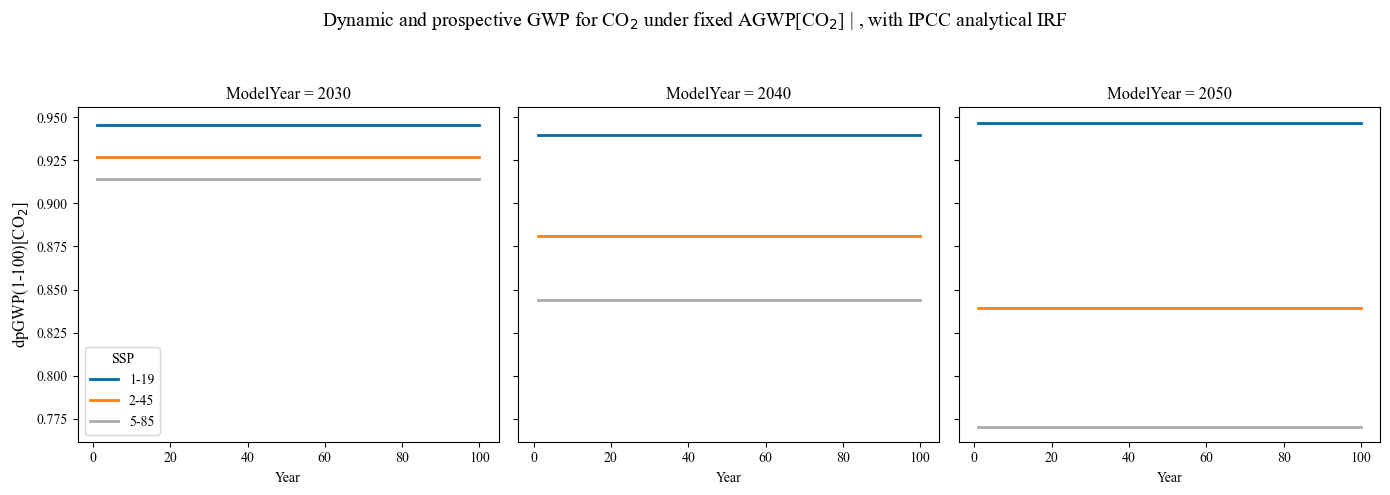

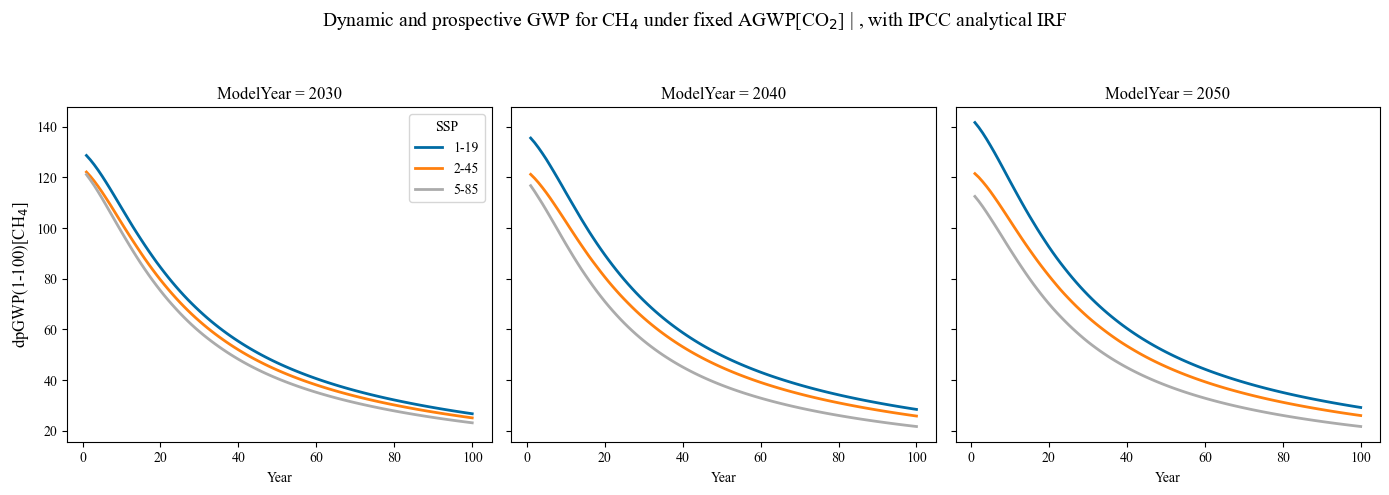

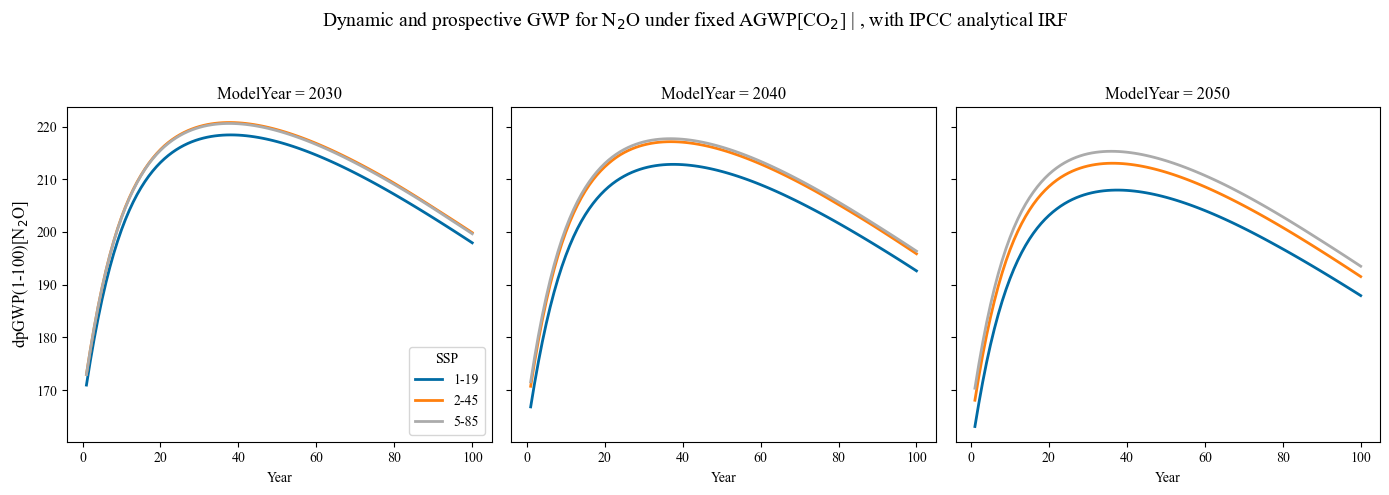

In [27]:
# same outputs as module B section, now for module C
plot_single_gas_panels(gwp_results_modB, 'CO2', ', with IPCC analytical IRF')
plot_single_gas_panels(gwp_results_modB, 'CH4', ', with IPCC analytical IRF')
plot_single_gas_panels(gwp_results_modB, 'N2O', ', with IPCC analytical IRF')


In [33]:
df_modB = build_gwp_dataframe(gwp_results_modB, strip_ssp_prefix=True, integer_dims=True)

cf_df_filtered_modB, cf_xr_modB, cf_xr2_modB = export_gwp_outputs(
    df_formatted=df_modB,
    out_dir='output_dpGWP_fixedCO2_v2026_wh_modB',
    excel_name='dpGWP_CO2CH4N2O_output_fixed_AGWPCO2_modB.xlsx',
    nc_name_gwp0='CF_GWP0_100_perSSP_MY_majorghgs_ModB.nc',
    nc_name_gwp1='CF_GWP1_100_perSSP_MY_majorghgs_ModB.nc',
)

print(df_modB.shape, cf_df_filtered_modB.shape)
df_modB

(909, 3) (900, 3)


CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                  
119 2030      0     0.000000    0.000000    0.000000
              1     0.945684  128.642366  170.949474
              2     0.945684  126.928209  175.554756
              3     0.945684  124.985695  179.799718
              4     0.945684  122.854093  183.662784
...                      ...         ...         ...
585 2050      96    0.770407   22.472404  195.437515
              97    0.770407   22.282256  194.956082
              98    0.770407   22.095961  194.472989
              99    0.770407   21.912990  193.988329
              100   0.770407   21.733252  193.502192

[909 rows x 3 columns]

# A: with the update RE, and old module B IPCC impulse response function [to use the metric folder :: metrics_2026-02-23]

#### read in all AGWP[CO2/CH4/N2O], under fixed_AGWPCO2 approach, a future CO2 itself no longer has GWP=1 

In [3]:
ghggass = ['CO2', 'CH4', 'N2O']

from collections import defaultdict
#  3-layer nested dict
cf_col_gas_allgas = defaultdict(lambda: defaultdict(dict))

for ghggas in ghggass: 
    cf_col_gas = []
    for sp in ssps:
        for MY in MYs:
            #print(f"read point GWP value for {ghggas} SSP {sp}, model year {MY}")
            filename = "agwp_dcf_gwp100_tstep1" + ghggas + "_ssp" + sp + "_fair_start1750MY" + str(MY) + ".xlsx"
            cf_file = os.path.join("../FaIR_dpCFs/output/metrics_2026-02-23/", filename)

            cf_agwp_df = pd.read_excel(cf_file, sheet_name = "agwp_pointvalue" + ghggas+ "_" + str(MY) ) 
            cf_agwp_pointvalue = cf_agwp_df[ghggas].values
            cf_col_gas.append(cf_agwp_pointvalue)
    
            cf_col_gas_allgas[ghggas][f'ssp{sp}'][str(MY)] = cf_agwp_pointvalue

##### read fixed AGWP[CO2,2019] value

In [4]:
agwp_co2 =  pd.read_excel('AGWP_CO2_fixed.xlsx' )
agwp_co2_TH101 = agwp_co2.iloc[:101]
#agwp_co2_TH101
agwp_co2_vals = agwp_co2_TH101['AGWP_CO2_fixed'].values[1:]  # shape (100,)
agwp_co2_vals.shape

(100,)

### AGWP[future CO2/CH4/N2O] / AGWP[2019 CO2] 

In [5]:
# Output dictionary to store GWP values
gwp_results = {}

for ghg in cf_col_gas_allgas:
    gwp_results[ghg] = {}
    for ssp in cf_col_gas_allgas[ghg]:
        gwp_results[ghg][ssp] = {}
        
        for MY in cf_col_gas_allgas[ghg][ssp]:
            arr = cf_col_gas_allgas[ghg][ssp][MY]

            arr_trimmed = arr[1:101]  # drops 0th element, keeps next 100

            # get GWP values (elementwise divide by CO2 AGWP)
            gwp_array = arr_trimmed / agwp_co2_vals

            # Store result
            gwp_results[ghg][ssp][MY] = gwp_array

In [6]:
gwp_results['CO2']['ssp119']['2030']

array([0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568393,
       0.94568393, 0.94568393, 0.94568393, 0.94568393, 0.94568

In [7]:
gwp_results['CH4']['ssp119']['2050']

array([141.64036661, 139.71138296, 137.51876433, 135.09884331,
       132.52448991, 129.85599526, 127.0854244 , 124.25243687,
       121.37705206, 118.51273609, 115.6890924 , 112.88712821,
       110.11865059, 107.40880118, 104.76749542, 102.22346675,
        99.69018261,  97.25996428,  94.89294437,  92.57276634,
        90.35099428,  88.21228828,  86.15835999,  84.18367858,
        82.25630661,  80.39845977,  78.6071465 ,  76.87451741,
        75.21580075,  73.61723277,  72.07522796,  70.59153959,
        69.15997245,  67.77969729,  66.44860846,  65.16466075,
        63.92541401,  62.72275166,  61.56469405,  60.45003562,
        59.37116836,  58.32845283,  57.32078911,  56.34688024,
        55.40769303,  54.4957555 ,  53.61317152,  52.75868407,
        51.93331594,  51.1348728 ,  50.36080902,  49.61011337,
        48.88182197,  48.17501609,  47.48882017,  46.82372543,
        46.1759448 ,  45.54600655,  44.93402436,  44.33911817,
        43.7607836 ,  43.1986634 ,  42.6514157 ,  42.11

#### plot on single gas

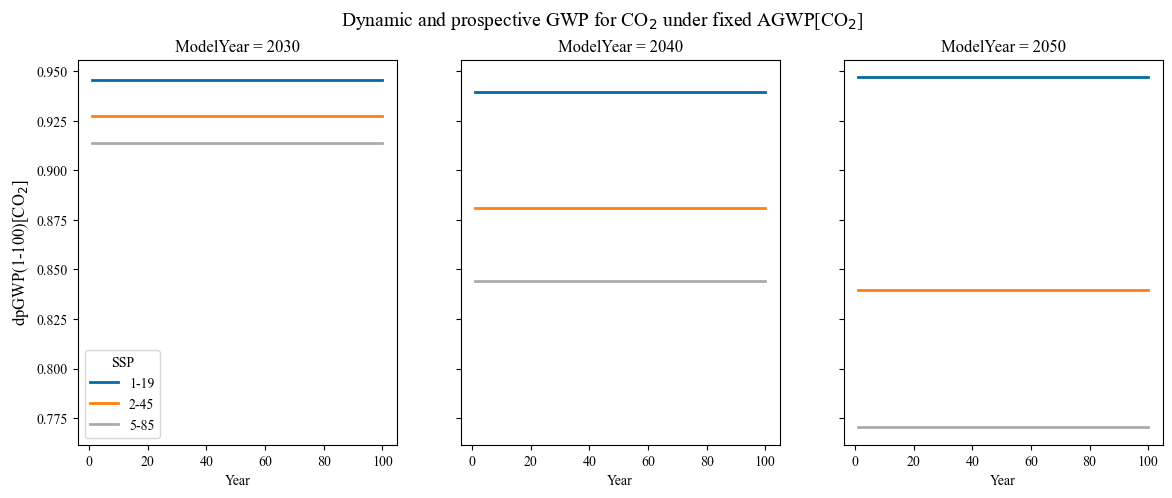

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['CO2'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[CO$_2$]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for CO$_2$ under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()


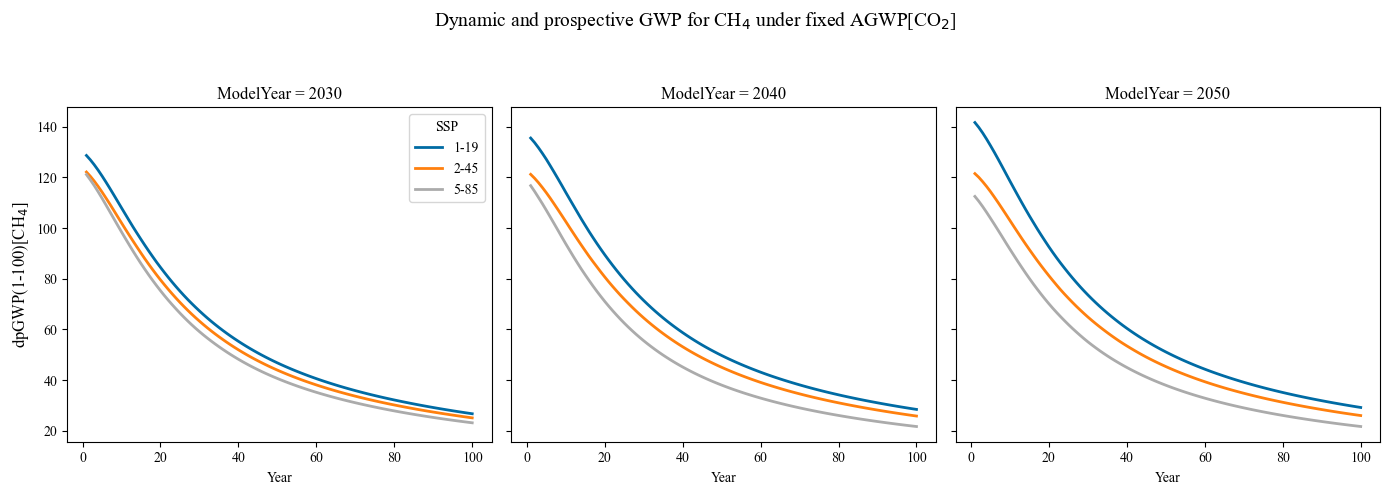

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['CH4'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[CH$_4$]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for CH$_4$ under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

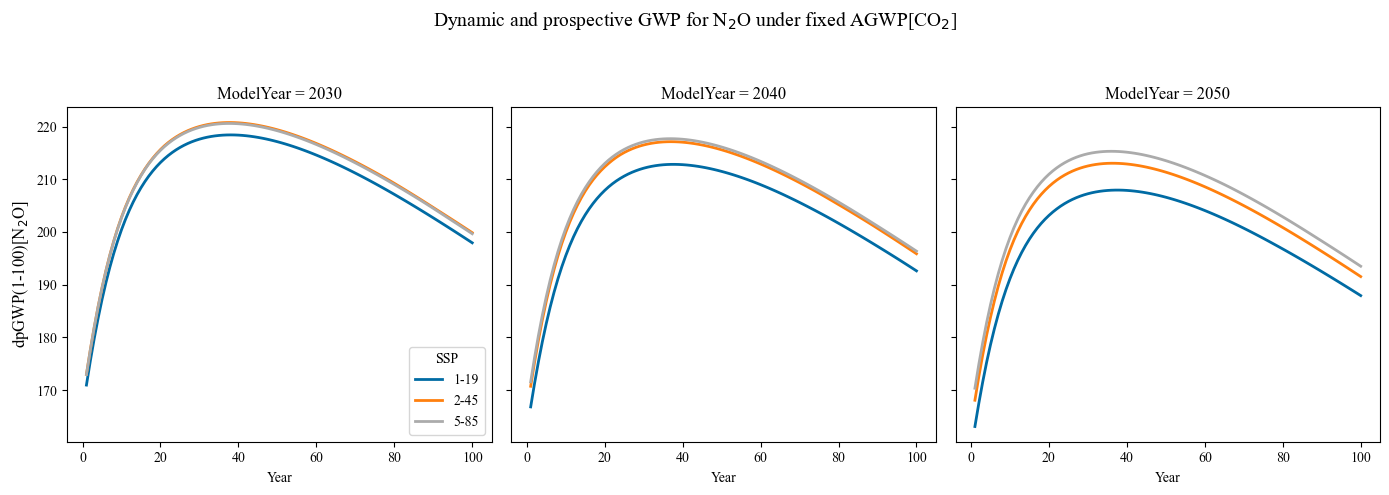

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['N2O'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[N$_2$O]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for N$_2$O under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### we'll combine the new GWP[CO2] (GWP[CO2]!= 1) with CH4/N2O in a new df and .nc 

In [11]:
records = []

for ssp in gwp_results['CH4'].keys():
    for my in gwp_results['CH4'][ssp].keys():
        # Add Year 0 first
        records.append((ssp, my, 0, 0.0, 0.0, 0.0))  # CO2 no longer 1, all gas append 0 for y[0]
        for year in range(1, 101):
            co2 = gwp_results['CO2'][ssp][my][year - 1] # no longer = 1 as static CO2 GWP
            ch4 = gwp_results['CH4'][ssp][my][year - 1]
            n2o = gwp_results['N2O'][ssp][my][year - 1]
            records.append((ssp, my, year, co2, ch4, n2o))

# Step 2: Create DataFrame
df = pd.DataFrame(records, columns=["SSP", "ModelYear", "Year", "CO2_GWP", "CH4_GWP", "N2O_GWP"])
df = df.set_index(["SSP", "ModelYear", "Year"])
df

CO2_GWP     CH4_GWP     N2O_GWP
SSP    ModelYear Year                                  
ssp119 2030      0     0.000000    0.000000    0.000000
                 1     0.945684  128.642366  170.949474
                 2     0.945684  126.928209  175.554756
                 3     0.945684  124.985695  179.799718
                 4     0.945684  122.854093  183.662784
...                         ...         ...         ...
ssp585 2050      96    0.770407   22.472404  195.437515
                 97    0.770407   22.282256  194.956082
                 98    0.770407   22.095961  194.472989
                 99    0.770407   21.912990  193.988329
                 100   0.770407   21.733252  193.502192

[909 rows x 3 columns]

In [12]:
df.to_excel("dpGWP_v2026_CO2CH4N2O_output_fixed_AGWPCO2.xlsx", index = True)

#### to later add to BW2-LCIA:: make sure SSP dim has the right name, no 'ssp' only 119, and MY dim has to be integer 

In [13]:
records = []

for ssp in gwp_results['CH4'].keys():
    for my in gwp_results['CH4'][ssp].keys():
        # Add Year 0 first
        records.append((ssp, my, 0, 0.0, 0.0, 0.0))  # CO2 no longer 1, all gas append 0 for y[0]
        for year in range(1, 101):
            co2 = gwp_results['CO2'][ssp][my][year - 1] # no longer = 1 as static CO2 GWP
            ch4 = gwp_results['CH4'][ssp][my][year - 1]
            n2o = gwp_results['N2O'][ssp][my][year - 1]
            records.append((ssp, my, year, co2, ch4, n2o))

df = pd.DataFrame(records, columns=["SSP", "ModelYear", "Year", "CO2_GWP", "CH4_GWP", "N2O_GWP"])
# to rename SSP column: 
df['SSP'] = df['SSP'].str.replace('ssp', '', regex=False)
# integer type for year columns
df['ModelYear'] = df['ModelYear'].astype(int)
df['Year'] = df['Year'].astype(int)

df = df.set_index(["SSP", "ModelYear", "Year"])
df

CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                  
119 2020      0     0.000000    0.000000    0.000000
              1     0.977034  124.711890  174.624103
              2     0.977034  122.708084  179.353413
              3     0.977034  120.505914  183.710051
              4     0.977034  118.163336  187.700423
...                      ...         ...         ...
585 2050      96    0.770407   22.472404  195.437515
              97    0.770407   22.282256  194.956082
              98    0.770407   22.095961  194.472989
              99    0.770407   21.912990  193.988329
              100   0.770407   21.733252  193.502192

[1212 rows x 3 columns]

In [14]:
#Deleting rows with YEAR_index value 0
cf_df_filtered = df[~df.index.get_level_values("Year").isin([0])]
#cf_df_filtered
print(len(df), len(cf_df_filtered))

1212 1200


In [15]:
cf_xr = df.to_xarray() 
cf_xr2 = cf_df_filtered.to_xarray() 

In [16]:
cf_xr.to_netcdf('output_dpGWP_fixedCO2/CF_v2026_GWP0_100_perSSP_MY_majorghgs.nc')
cf_xr2.to_netcdf('output_dpGWP_fixedCO2/CF_v2026_GWP1_100_perSSP_MY_majorghgs.nc')

In [17]:
cf_xr2

<xarray.Dataset>
Dimensions:    (SSP: 3, ModelYear: 4, Year: 100)
Coordinates:
  * SSP        (SSP) object '119' '245' '585'
  * ModelYear  (ModelYear) int64 2020 2030 2040 2050
  * Year       (Year) int64 1 2 3 4 5 6 7 8 9 10 ... 92 93 94 95 96 97 98 99 100
Data variables:
    CO2_GWP    (SSP, ModelYear, Year) float64 0.977 0.977 ... 0.7704 0.7704
    CH4_GWP    (SSP, ModelYear, Year) float64 124.7 122.7 120.5 ... 21.91 21.73
    N2O_GWP    (SSP, ModelYear, Year) float64 174.6 179.4 183.7 ... 194.0 193.5

# B: now with the new module C, with prospective decay factor   [to use the metric folder :: metrics_AGWP_wh_ModC_CC_T] 

In [13]:

# ---- metric with module C: fixed-CO2 dpGWP built from the new prospective-decay-factor AGWP metric ----
metric_dir_modC = "../FaIR_dpCFs/output/metrics_AGWP_wh_ModC_CC_T/"
filename_template_modC = "agwp_by_pIRF_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"

cf_col_gas_allgas_modC = load_agwp_pointvalue_dict(
    metric_dir=metric_dir_modC,
    filename_template=filename_template_modC,
    ghg_list=ghggass,
    ssps=ssps,
    MYs=MYs,
)

# quick spot checks
cf_col_gas_allgas_modC['CO2']['ssp119']['2030'][:5], cf_col_gas_allgas_modC['CH4']['ssp119']['2030'][:5]




(array([0.00000000e+00, 1.55489084e-15, 3.00654236e-15, 4.38917558e-15,
        5.71493928e-15]),
 array([0.00000000e+00, 2.13754886e-13, 4.11020961e-13, 5.92965196e-13,
        7.60539998e-13]))

In [14]:

gwp_results_modC = compute_fixed_co2_gwp(
    cf_col_gas_allgas=cf_col_gas_allgas_modC,
    agwp_co2_vals=agwp_co2_vals,
    len_cf=len_cf,
)


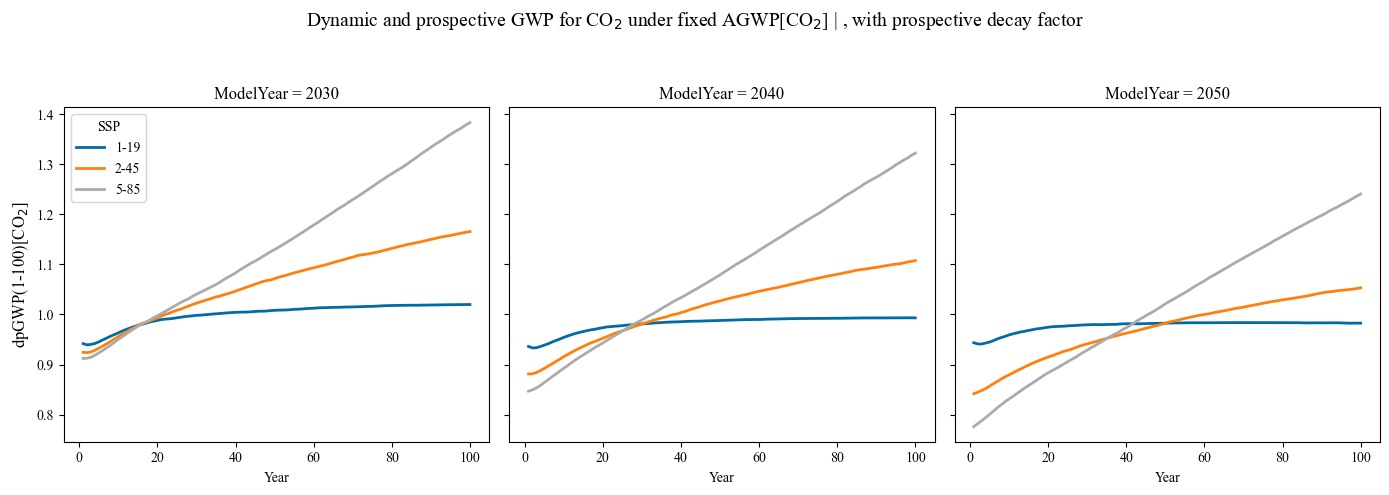

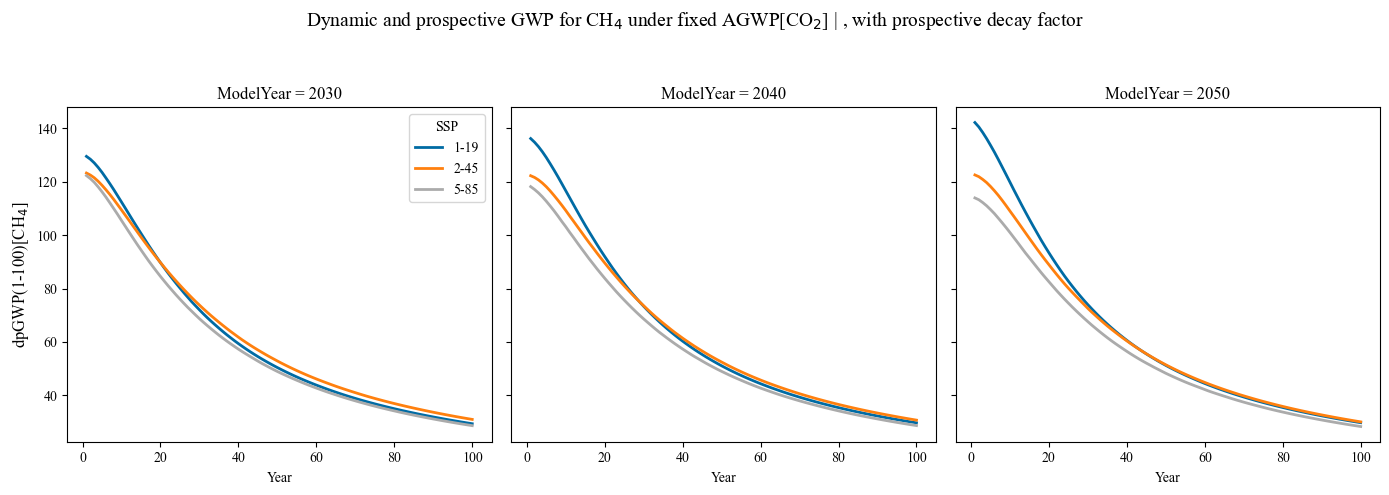

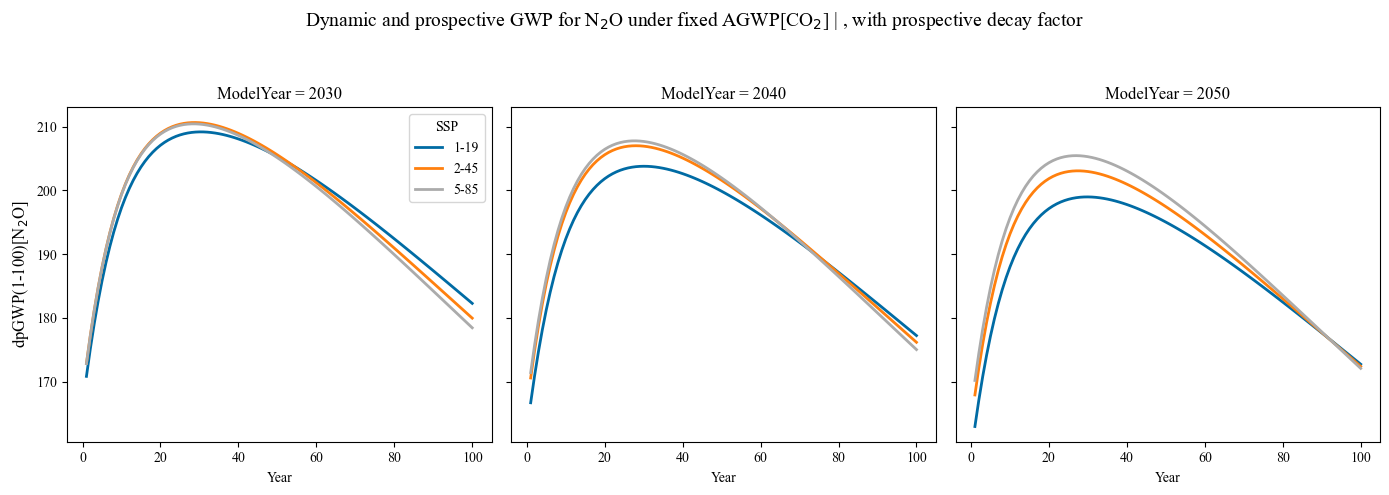

In [16]:

# same outputs as module B section, now for module C
plot_single_gas_panels(gwp_results_modC, 'CO2', ', with prospective decay factor')
plot_single_gas_panels(gwp_results_modC, 'CH4', ', with prospective decay factor')
plot_single_gas_panels(gwp_results_modC, 'N2O', ', with prospective decay factor')



In [17]:
# same style of output df for inspection
df_modC_raw = build_gwp_dataframe(gwp_results_modC, strip_ssp_prefix=False, integer_dims=False)
df_modC_raw



CO2_GWP     CH4_GWP     N2O_GWP
SSP    ModelYear Year                                  
ssp119 2030      0     0.000000    0.000000    0.000000
                 1     0.941822  129.474722  170.824170
                 2     0.939335  128.415469  175.169989
                 3     0.940314  127.033721  179.096258
                 4     0.941997  125.360343  182.631564
...                         ...         ...         ...
ssp585 2050      96    1.223201   29.261828  174.365730
                 97    1.227364   29.024647  173.792580
                 98    1.231855   28.792021  173.219905
                 99    1.236425   28.563567  172.647777
                 100   1.240817   28.338891  172.076269

[909 rows x 3 columns]

In [18]:
# BW2-LCIA ready version: SSP without 'ssp', ModelYear/Year as integers
df_modC = build_gwp_dataframe(gwp_results_modC, strip_ssp_prefix=True, integer_dims=True)

cf_df_filtered_modC, cf_xr_modC, cf_xr2_modC = export_gwp_outputs(
    df_formatted=df_modC,
    out_dir='output_dpGWP_fixedCO2_v2026_wh_modC',
    excel_name='dpGWP_CO2CH4N2O_output_fixed_AGWPCO2_modC.xlsx',
    nc_name_gwp0='CF_GWP0_100_perSSP_MY_majorghgs_ModC.nc',
    nc_name_gwp1='CF_GWP1_100_perSSP_MY_majorghgs_ModC.nc',
)

print(df_modC.shape, cf_df_filtered_modC.shape)
df_modC

(909, 3) (900, 3)


CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                  
119 2030      0     0.000000    0.000000    0.000000
              1     0.941822  129.474722  170.824170
              2     0.939335  128.415469  175.169989
              3     0.940314  127.033721  179.096258
              4     0.941997  125.360343  182.631564
...                      ...         ...         ...
585 2050      96    1.223201   29.261828  174.365730
              97    1.227364   29.024647  173.792580
              98    1.231855   28.792021  173.219905
              99    1.236425   28.563567  172.647777
              100   1.240817   28.338891  172.076269

[909 rows x 3 columns]

# C: now benchmark metric calculated by A vs. B

In [35]:
df_modC

CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                  
119 2030      0     0.000000    0.000000    0.000000
              1     0.941822  129.474722  170.824170
              2     0.939335  128.415469  175.169989
              3     0.940314  127.033721  179.096258
              4     0.941997  125.360343  182.631564
...                      ...         ...         ...
585 2050      96    1.223201   29.261828  174.365730
              97    1.227364   29.024647  173.792580
              98    1.231855   28.792021  173.219905
              99    1.236425   28.563567  172.647777
              100   1.240817   28.338891  172.076269

[909 rows x 3 columns]

In [36]:
def wide_to_long_for_benchmark(df_wide, approach_name):
    long_df = (
        df_wide
        .reset_index()
        .melt(
            id_vars=['SSP', 'ModelYear', 'Year'],
            value_vars=['CO2_GWP', 'CH4_GWP', 'N2O_GWP'],
            var_name='Gas',
            value_name='dpGWP',
        )
    )
    long_df['Gas'] = long_df['Gas'].str.replace('_GWP', '', regex=False)
    long_df['Approach'] = approach_name
    return long_df

def standardize_benchmark_keys(df_long):
    df_long = df_long.copy()

    # make key formatting identical on both sides
    df_long['SSP'] = df_long['SSP'].astype(str).str.strip().str.replace('ssp', '', regex=False)
    df_long['Gas'] = df_long['Gas'].astype(str).str.strip()

    df_long['ModelYear'] = pd.to_numeric(df_long['ModelYear'], errors='coerce').astype('Int64')
    df_long['Year'] = pd.to_numeric(df_long['Year'], errors='coerce').astype('Int64')

    return df_long

long_modB = standardize_benchmark_keys(wide_to_long_for_benchmark(df_modB, 'Module B'))
long_modC = standardize_benchmark_keys(wide_to_long_for_benchmark(df_modC, 'Module C'))

benchmark_df = (
    long_modB
    .merge(
        long_modC,
        on=['SSP', 'ModelYear', 'Year', 'Gas'],
        suffixes=('_ModB', '_ModC'),
        how='inner',
        validate='one_to_one',
    )
    .drop(columns=['Approach_ModB', 'Approach_ModC'])
)

benchmark_df['abs_diff'] = benchmark_df['dpGWP_ModC'] - benchmark_df['dpGWP_ModB']
benchmark_df['abs_diff_abs'] = benchmark_df['abs_diff'].abs()
benchmark_df['pct_diff_vs_ModB'] = np.where(
    benchmark_df['dpGWP_ModB'] != 0,
    100 * benchmark_df['abs_diff'] / benchmark_df['dpGWP_ModB'],
    np.nan,
)
benchmark_df['pct_diff_abs'] = benchmark_df['pct_diff_vs_ModB'].abs()

print("benchmark_df shape:", benchmark_df.shape)
display(benchmark_df.head(12))


benchmark_df shape: (2727, 10)


,SSP,ModelYear,Year,Gas,dpGWP_ModB,dpGWP_ModC,abs_diff,abs_diff_abs,pct_diff_vs_ModB,pct_diff_abs
0,119,2030,0,CO2,0.000000,0.000000,0.000000,0.000000,NaN,NaN
1,119,2030,1,CO2,0.945684,0.941822,-0.003862,0.003862,-0.408372,0.408372
2,119,2030,2,CO2,0.945684,0.939335,-0.006349,0.006349,-0.671315,0.671315
3,119,2030,3,CO2,0.945684,0.940314,-0.005370,0.005370,-0.567866,0.567866
4,119,2030,4,CO2,0.945684,0.941997,-0.003686,0.003686,-0.389821,0.389821
5,119,2030,5,CO2,0.945684,0.945282,-0.000402,0.000402,-0.042465,0.042465
6,119,2030,6,CO2,0.945684,0.949163,0.003479,0.003479,0.367873,0.367873
7,119,2030,7,CO2,0.945684,0.952802,0.007118,0.007118,0.752697,0.752697
8,119,2030,8,CO2,0.945684,0.956579,0.010895,0.010895,1.152112,1.152112
9,119,2030,9,CO2,0.945684,0.959903,0.014219,0.014219,1.503534,1.503534


In [37]:
# summary table by gas / SSP / model year
summary_stats = (
    benchmark_df[benchmark_df['Year'] > 0]
    .groupby(['Gas', 'SSP', 'ModelYear'], as_index=False)
    .agg(
        mean_ModB=('dpGWP_ModB', 'mean'),
        mean_ModC=('dpGWP_ModC', 'mean'),
        mean_abs_diff=('abs_diff', 'mean'),
        mean_abs_diff_abs=('abs_diff_abs', 'mean'),
        max_abs_diff_abs=('abs_diff_abs', 'max'),
        mean_pct_diff=('pct_diff_vs_ModB', 'mean'),
        max_pct_diff_abs=('pct_diff_abs', 'max'),
    )
)

for H in [20, 50, 100]:
    tmp = benchmark_df[benchmark_df['Year'] == H][['Gas', 'SSP', 'ModelYear', 'dpGWP_ModB', 'dpGWP_ModC', 'abs_diff', 'pct_diff_vs_ModB']].copy()
    tmp = tmp.rename(columns={
        'dpGWP_ModB': f'ModB_H{H}',
        'dpGWP_ModC': f'ModC_H{H}',
        'abs_diff': f'abs_diff_H{H}',
        'pct_diff_vs_ModB': f'pct_diff_H{H}',
    })
    summary_stats = summary_stats.merge(tmp, on=['Gas', 'SSP', 'ModelYear'], how='left')

summary_stats = summary_stats.sort_values(['Gas', 'ModelYear', 'SSP']).reset_index(drop=True)
display(summary_stats)

summary_by_gas = (
    benchmark_df[benchmark_df['Year'] > 0]
    .groupby('Gas', as_index=False)
    .agg(
        mean_ModB=('dpGWP_ModB', 'mean'),
        mean_ModC=('dpGWP_ModC', 'mean'),
        mean_abs_diff=('abs_diff', 'mean'),
        max_abs_diff_abs=('abs_diff_abs', 'max'),
        mean_pct_diff=('pct_diff_vs_ModB', 'mean'),
        max_pct_diff_abs=('pct_diff_abs', 'max'),
    )
)

display(summary_by_gas)

,Gas,SSP,ModelYear,mean_ModB,mean_ModC,mean_abs_diff,mean_abs_diff_abs,max_abs_diff_abs,mean_pct_diff,max_pct_diff_abs,...,abs_diff_H20,pct_diff_H20,ModB_H50,ModC_H50,abs_diff_H50,pct_diff_H50,ModB_H100,ModC_H100,abs_diff_H100,pct_diff_H100
0,CH4,119,2030,57.216604,60.792935,3.576331,3.576331,5.211713,7.227831,9.808673,...,5.165225,6.112249,46.824074,50.405750,3.581677,7.649221,26.760999,29.385897,2.624899,9.808673
1,CH4,245,2030,53.882255,61.798457,7.916202,7.916202,10.552986,17.695561,23.339348,...,10.124801,12.724486,43.971361,52.871161,8.899800,20.239992,25.136654,31.003385,5.866731,23.339348
2,CH4,585,2030,50.814048,58.178628,7.364580,7.364580,9.629426,17.750606,23.620056,...,9.217583,12.240354,40.670742,48.938155,8.267413,20.327668,23.186926,28.663690,5.476765,23.620056
3,CH4,119,2040,60.650159,62.220730,1.570571,1.570571,2.634625,2.890138,4.406730,...,2.492804,2.785231,49.750983,51.072738,1.321754,2.656740,28.469875,29.724466,1.254591,4.406730
4,CH4,245,2040,54.767825,61.459674,6.691849,6.691849,9.053613,14.455485,18.863071,...,8.836173,10.944167,45.087840,52.476685,7.388844,16.387666,25.856366,30.733670,4.877305,18.863071
5,CH4,585,2040,47.945955,57.684976,9.739022,9.739022,13.158521,24.823130,32.095536,...,12.740046,17.918601,38.071630,48.979736,10.908107,28.651536,21.721701,28.693397,6.971696,32.095536
6,CH4,119,2050,62.638699,63.063182,0.424483,0.424483,1.286884,0.690116,1.841288,...,0.786723,0.849843,51.134873,51.215832,0.080959,0.158325,29.237626,29.775975,0.538349,1.841288
7,CH4,245,2050,55.063286,60.732288,5.669003,5.669003,7.822743,12.028010,15.478696,...,7.731646,9.523567,45.366505,51.444802,6.078298,13.398206,26.051977,30.084483,4.032506,15.478696
8,CH4,585,2050,47.382765,56.685522,9.302757,9.302757,12.594906,23.667277,30.394163,...,12.399694,17.682095,37.997265,48.263120,10.265855,27.017352,21.733252,28.338891,6.605640,30.394163
9,CO2,119,2030,0.945684,1.000892,0.055208,0.055602,0.074227,5.837909,7.849037,...,0.042460,4.489830,0.945684,1.008284,0.062600,6.619523,0.945684,1.019911,0.074227,7.849037


,Gas,mean_ModB,mean_ModC,mean_abs_diff,max_abs_diff_abs,mean_pct_diff,max_pct_diff_abs
0,CH4,54.484622,60.290710,5.806089,13.158521,13.469795,32.095536
1,CO2,0.889825,1.028543,0.138719,0.478127,16.118089,61.059900
2,N2O,206.591833,194.553267,-12.038566,21.425923,-5.802664,11.072703


# plot benchmark

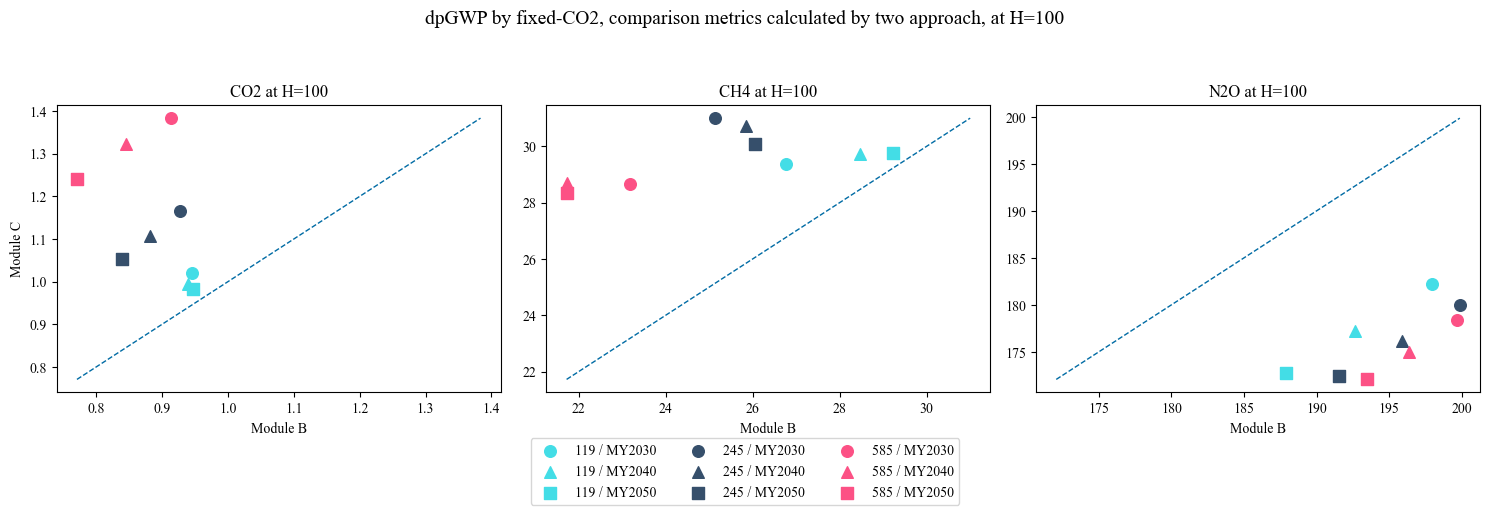

In [55]:
# define encodings
markers = {2030: 'o', 2040: '^', 2050: 's'}
colors = {'119': '#43dde6', '245': '#364f6b', '585': '#fc5185'}  

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=False, sharey=False)

for i, gas in enumerate(gas_order):
    ax = axes[i]
    sub = h100[h100['Gas'] == gas].copy()

    for (ssp, my), s in sub.groupby(['SSP', 'ModelYear']):
        ax.scatter(
            s['dpGWP_ModB'],
            s['dpGWP_ModC'],
            marker=markers[my],
            color=colors[ssp],
            s=70,
            label=f"{ssp.upper()} / MY{my}"
        )

    # 1:1 line
    xy_min = min(sub['dpGWP_ModB'].min(), sub['dpGWP_ModC'].min())
    xy_max = max(sub['dpGWP_ModB'].max(), sub['dpGWP_ModC'].max())
    ax.plot([xy_min, xy_max], [xy_min, xy_max], linestyle='--', linewidth=1)

    ax.set_title(f"{gas} at H=100")
    ax.set_xlabel("Module B")
    if i == 0:
        ax.set_ylabel("Module C")

# remove duplicate legends
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc='lower center',
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.136)   # <-- move outside
)

fig.suptitle("dpGWP by fixed-CO2, comparison metrics calculated by two approach, at H=100", fontsize=14)


plt.tight_layout(rect=[0, 0, 1, 0.92])

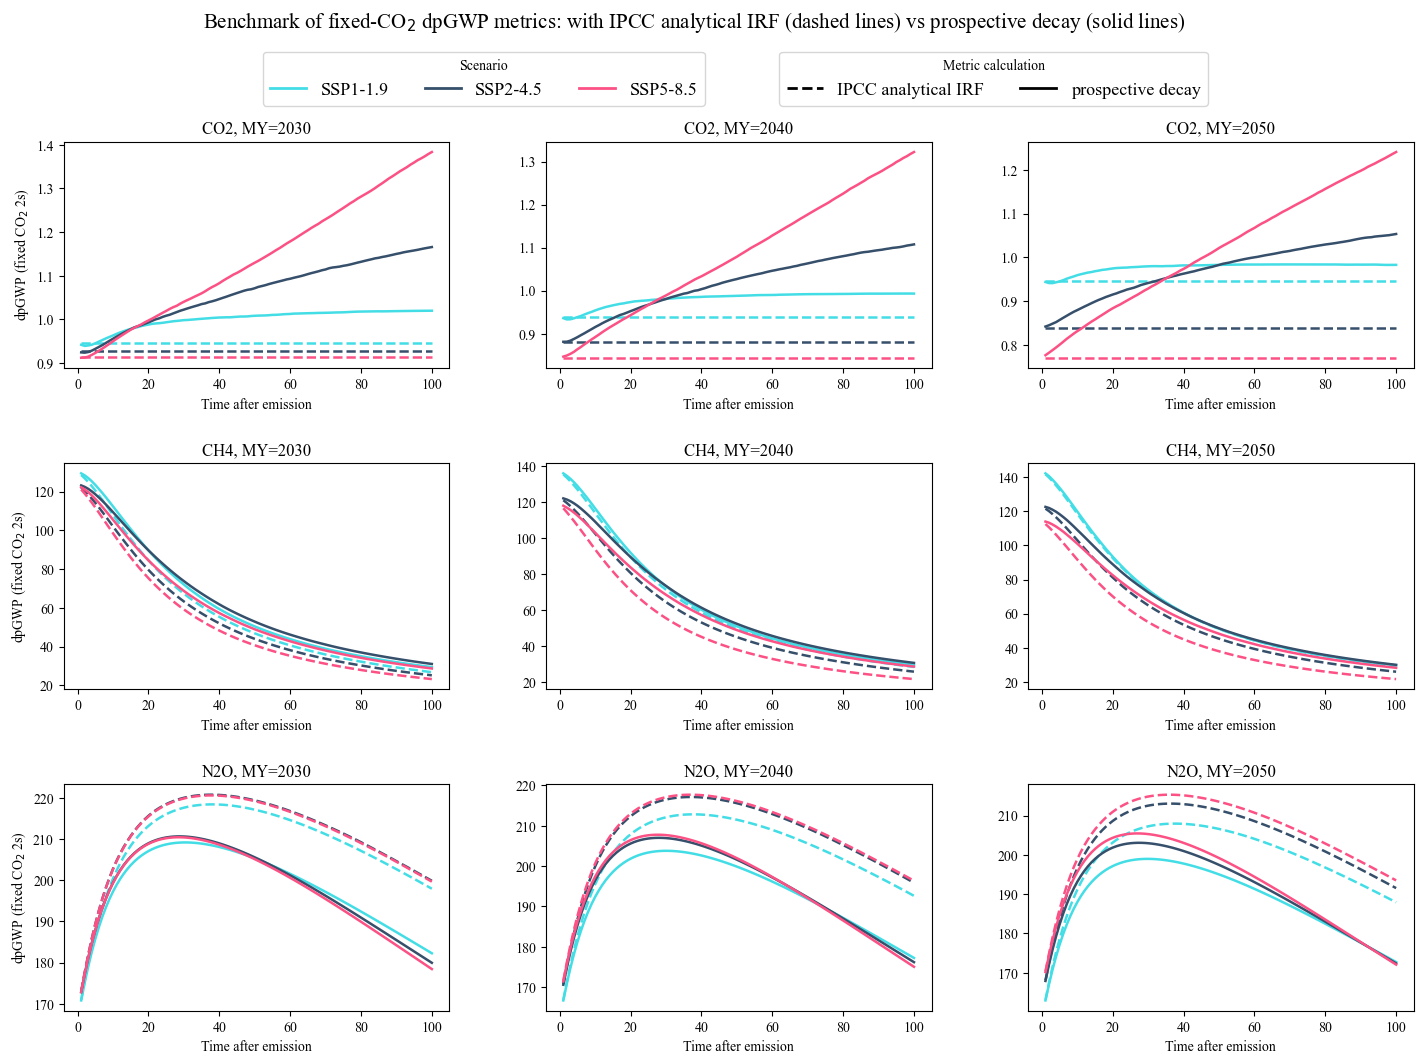

In [65]:
# one big 3x3 comparison plot with shared legend
from matplotlib.lines import Line2D

ssp_labels = {'119': 'SSP1-1.9', '245': 'SSP2-4.5', '585': 'SSP5-8.5'}
ssp_colors =  {'119': '#43dde6', '245': '#364f6b', '585': '#fc5185'}  


gas_order = ['CO2', 'CH4', 'N2O']
my_order = [2030, 2040, 2050]

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=False)

for r, gas in enumerate(gas_order):
    for c, my in enumerate(my_order):
        ax = axes[r, c]
        sub = benchmark_df[
            (benchmark_df['Gas'] == gas) &
            (benchmark_df['ModelYear'] == my) &
            (benchmark_df['Year'] > 0)
        ].copy()

        for ssp in ['119', '245', '585']:
            s = sub[sub['SSP'] == ssp].sort_values('Year')
            if s.empty:
                continue

            color = ssp_colors[ssp]

            ax.plot(
                s['Year'], s['dpGWP_ModB'],
                linestyle='--',
                color=color,
                linewidth=1.8
            )
            ax.plot(
                s['Year'], s['dpGWP_ModC'],
                linestyle='-',
                color=color,
                linewidth=1.8
            )

        ax.set_title(f"{gas}, MY={my}", fontsize=12)
        ax.set_xlabel("Time after emission")

        if c == 0:
            ax.set_ylabel("dpGWP (fixed CO$_2$ 2s)")

        ax.grid(False)

# shared legends
ssp_handles = [
    Line2D([0], [0], color=ssp_colors[k], lw=2, label=ssp_labels[k])
    for k in ['119', '245', '585']
]
method_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='IPCC analytical IRF'),
    Line2D([0], [0], color='black', lw=2, linestyle='-', label='prospective decay'),
]


# Scenario legend (left)
fig.legend(
    handles=ssp_handles,
    loc='upper center',
    fontsize = 13,
    bbox_to_anchor=(0.36, 0.95),
    ncol=3,
    frameon=True,
    title="Scenario"
)

# Method legend (right)
fig.legend(
    handles=method_handles,
    loc='upper center',
    fontsize = 13,
    bbox_to_anchor=(0.7, 0.95),
    ncol=2,
    frameon=True,
    title="Metric calculation"
)



fig.suptitle("Benchmark of fixed-CO$_2$ dpGWP metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)", fontsize=15)

fig.subplots_adjust(
    top=0.86,
    bottom=0.07,
    left=0.08,
    right=0.98,
    hspace=0.42,
    wspace=0.25
)

plt.show()